<a href="https://colab.research.google.com/github/aaryapatkarworks/ML/blob/main/ML_Lab_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif


In [16]:
# Load the dataset (Ensure the CSV file is in the same folder)
columns = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin",
           "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]

df = pd.read_csv("pima_diabetes.csv", names=columns)


In [17]:
print("First 5 records:\n", df.head())
print("\nLast 5 records:\n", df.tail())
print("\nRows 4 to 12:\n", df.iloc[3:12])
print("\nFirst 19 records:\n", df.iloc[:19])

First 5 records:
    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0  Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI   
1            6      148             72             35        0  33.6   
2            1       85             66             29        0  26.6   
3            8      183             64              0        0  23.3   
4            1       89             66             23       94  28.1   

   DiabetesPedigreeFunction  Age  Outcome  
0  DiabetesPedigreeFunction  Age  Outcome  
1                     0.627   50        1  
2                     0.351   31        0  
3                     0.672   32        1  
4                     0.167   21        0  

Last 5 records:
     Pregnancies Glucose BloodPressure SkinThickness Insulin   BMI  \
764          10     101            76            48     180  32.9   
765           2     122            70            27       0  36.8   
766           5     121            72            23     112 

In [18]:
print("\nDataset Info:\n")
df.info()

print("\nStatistical Description:\n")
print(df.describe())



Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 769 entries, 0 to 768
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Pregnancies               769 non-null    object
 1   Glucose                   769 non-null    object
 2   BloodPressure             769 non-null    object
 3   SkinThickness             769 non-null    object
 4   Insulin                   769 non-null    object
 5   BMI                       769 non-null    object
 6   DiabetesPedigreeFunction  769 non-null    object
 7   Age                       769 non-null    object
 8   Outcome                   769 non-null    object
dtypes: object(9)
memory usage: 54.2+ KB

Statistical Description:

       Pregnancies Glucose BloodPressure SkinThickness Insulin  BMI  \
count          769     769           769           769     769  769   
unique          18     137            48            52     187  249   
top  

In [19]:
missing_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[missing_cols] = df[missing_cols].replace(0, np.nan)

print("\nMissing values per row:\n", df.isnull().sum(axis=1))
print("\nTotal rows with any missing value:", (df.isnull().sum(axis=1) > 0).sum())



Missing values per row:
 0      0
1      0
2      0
3      0
4      0
      ..
764    0
765    0
766    0
767    0
768    0
Length: 769, dtype: int64

Total rows with any missing value: 0


In [20]:
print("\nAge Column:\n", df["Age"])
print("\nColumn Index of 'Age':", df.columns.get_loc("Age"))



Age Column:
 0      Age
1       50
2       31
3       32
4       21
      ... 
764     63
765     27
766     30
767     47
768     23
Name: Age, Length: 769, dtype: object

Column Index of 'Age': 7


In [21]:
df.drop_duplicates(inplace=True)


In [22]:
imputer = SimpleImputer(strategy="mean")
df[missing_cols] = imputer.fit_transform(df[missing_cols])


ValueError: Cannot use mean strategy with non-numeric data:
could not convert string to float: 'Glucose'

In [23]:
df.drop_duplicates(inplace=True)


In [24]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]


In [25]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)


In [26]:
# Min-Max Normalization
minmax_scaler = MinMaxScaler()
X_minmax = minmax_scaler.fit_transform(X)

# Z-score Standardization
zscore_scaler = StandardScaler()
X_zscore = zscore_scaler.fit_transform(X)


ValueError: could not convert string to float: 'Pregnancies'

/tmp/ipython-input-28-2546343026.py:25: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df["Glucose"], shade=True)


TypeError: The x variable is categorical, but one of ['numeric', 'datetime'] is required

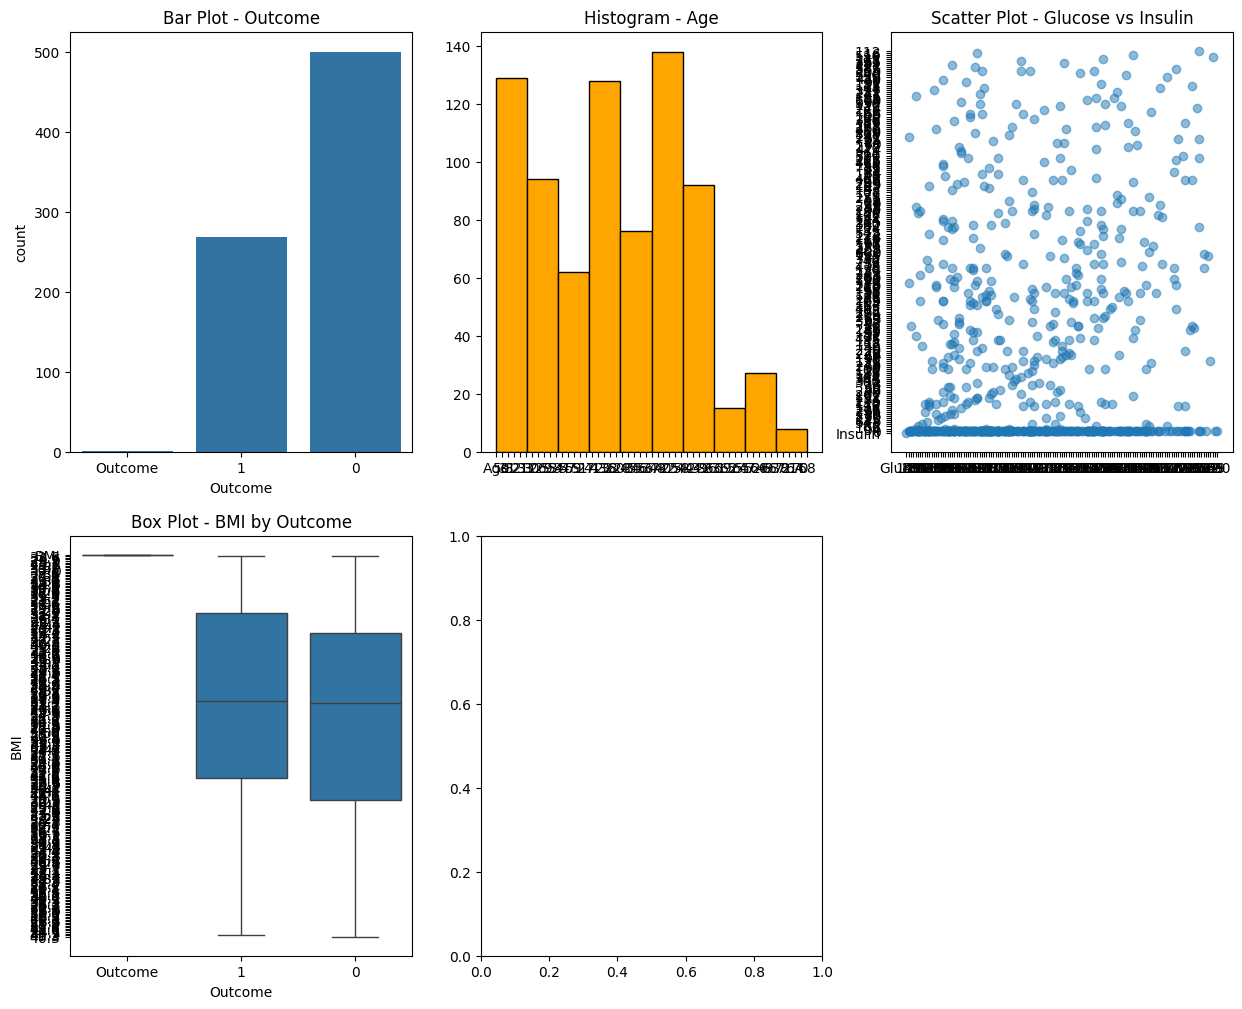

In [28]:
plt.figure(figsize=(15, 12))

# 1. Bar plot
plt.subplot(2, 3, 1)
sns.countplot(x="Outcome", data=df)
plt.title("Bar Plot - Outcome")

# 2. Histogram
plt.subplot(2, 3, 2)
plt.hist(df["Age"], bins=10, color='orange', edgecolor='black')
plt.title("Histogram - Age")

# 3. Scatter plot
plt.subplot(2, 3, 3)
plt.scatter(df["Glucose"], df["Insulin"], alpha=0.5)
plt.title("Scatter Plot - Glucose vs Insulin")

# 4. Box plot
plt.subplot(2, 3, 4)
sns.boxplot(x="Outcome", y="BMI", data=df)
plt.title("Box Plot - BMI by Outcome")

# 5. KDE Plot
plt.subplot(2, 3, 5)
sns.kdeplot(df["Glucose"], shade=True)
plt.title("KDE Plot - Glucose")

# 6. Violin Plot
plt.subplot(2, 3, 6)
sns.violinplot(x="Outcome", y="Age", data=df)
plt.title("Violin Plot - Age by Outcome")

plt.tight_layout()
plt.show()


In [29]:
corr_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


ValueError: could not convert string to float: 'Pregnancies'

In [30]:
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)

# Create DataFrame for scores
feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "Score": selector.scores_
}).sort_values(by="Score", ascending=False)

print("Feature Importance Scores:\n", feature_scores)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x="Score", y="Feature", data=feature_scores)
plt.title("Feature Importance using SelectKBest")
plt.xlabel("Score")
plt.ylabel("Feature")
plt.show()


ValueError: could not convert string to float: 'Pregnancies'